# Model Evaluation - Helmet Detection

This notebook evaluates the trained YOLOv8 model on unseen data.

Objectives:
- Run inference on validation/test images
- Visualize predictions
- Analyze model performance
- Identify failure cases


In [1]:
import os
import cv2
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

## Load Trained Model

We load the best-performing model obtained after training.

In [10]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
MODEL_PATH = os.path.join(PROJECT_ROOT, "runs", "detect", "runs", "exp", "weights", "best.pt")

model = YOLO(MODEL_PATH)
print(f"Model loaded successfully from {MODEL_PATH}")

Model loaded successfully from /Users/monimoybharadwaj/Desktop/Helmet Detection/runs/detect/runs/exp/weights/best.pt


## Dataset for Evaluation

We use the validation dataset to evaluate performance.

In [ ]:
VAL_PATH = os.path.join(PROJECT_ROOT, "data", "helmet_detection", "valid", "images")

image_files = [f for f in os.listdir(VAL_PATH) if not f.startswith(".")]

print(f"Total validation images: {len(image_files)}")

Total validation images: 3962


## Run Inference

We perform prediction on random validation images.


image 1/1 /Users/monimoybharadwaj/Desktop/Helmet Detection/data/helmet_detection/valid/images/-1135-_png_jpg.rf.3dfd851d616fe2ed95141e561e841041.jpg: 512x512 3 helmets, 116.9ms
Speed: 4.7ms preprocess, 116.9ms inference, 6.0ms postprocess per image at shape (1, 3, 512, 512)


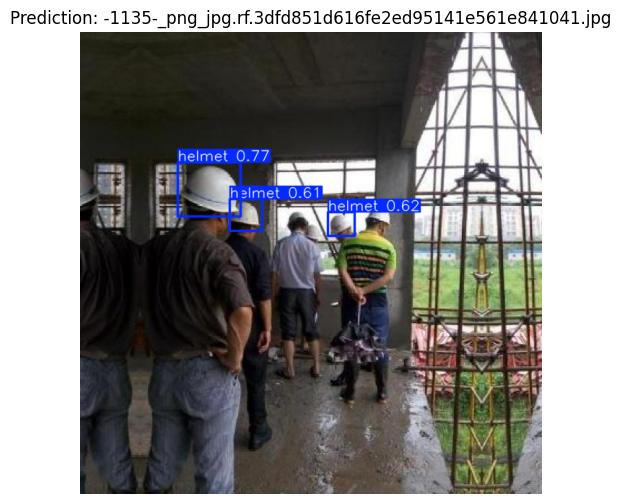


image 1/1 /Users/monimoybharadwaj/Desktop/Helmet Detection/data/helmet_detection/valid/images/ppe_0992_jpg.rf.89c7702096a405e5b23fdad066d3caf6.jpg: 512x512 2 helmets, 147.3ms
Speed: 1.8ms preprocess, 147.3ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 512)


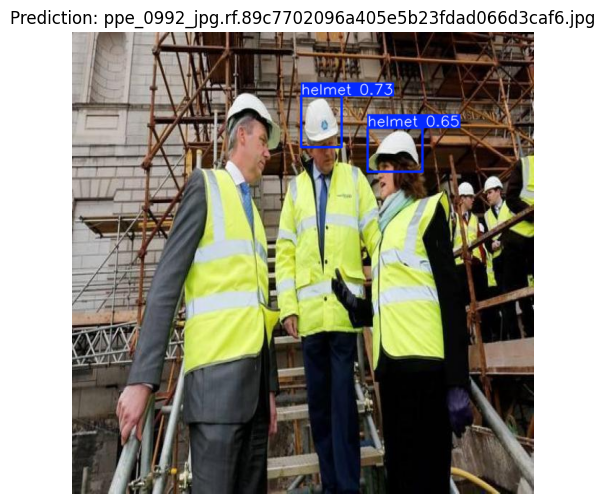


image 1/1 /Users/monimoybharadwaj/Desktop/Helmet Detection/data/helmet_detection/valid/images/004417_jpg.rf.76d2bc0b72f7a0d4b24f97f2d48ede82.jpg: 512x512 4 helmets, 167.9ms
Speed: 1.8ms preprocess, 167.9ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 512)


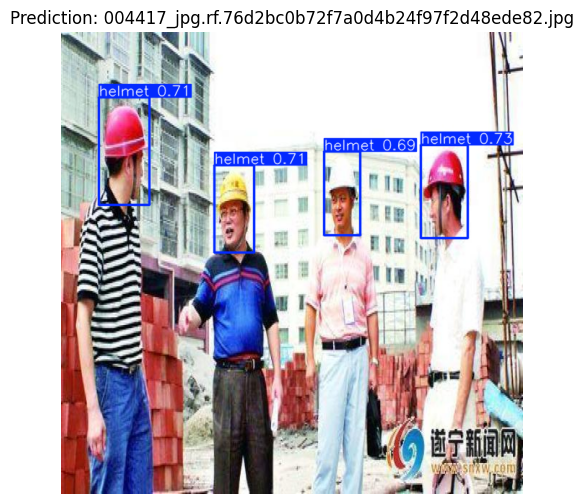


image 1/1 /Users/monimoybharadwaj/Desktop/Helmet Detection/data/helmet_detection/valid/images/-2159-_png_jpg.rf.de769ef648e569b7b29803424735a9b5.jpg: 512x512 2 helmets, 107.3ms
Speed: 1.6ms preprocess, 107.3ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 512)


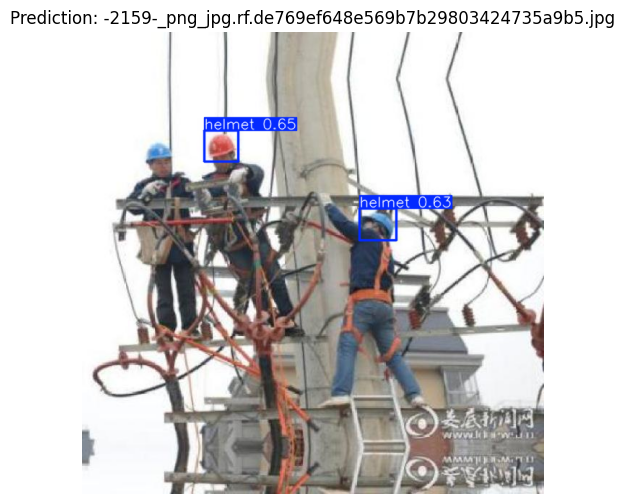


image 1/1 /Users/monimoybharadwaj/Desktop/Helmet Detection/data/helmet_detection/valid/images/-4537-_png_jpg.rf.688ba255a76522180c59ccadf4955c3f.jpg: 512x512 (no detections), 103.0ms
Speed: 2.0ms preprocess, 103.0ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 512)


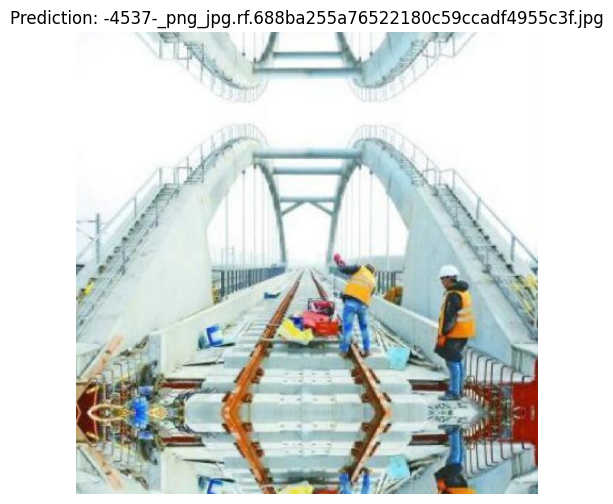

In [11]:
for _ in range(5):
    img_name = random.choice(image_files)

    img_path = os.path.join(VAL_PATH, img_name)

    results = model.predict(img_path, conf=0.6)

    annotated = results[0].plot()

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {img_name}")
    plt.axis("off")
    plt.show()

## Extract Detection Details

We extract class labels and confidence scores.

In [12]:
img_path = os.path.join(VAL_PATH, random.choice(image_files))

results = model.predict(img_path, conf=0.6)

boxes = results[0].boxes

detections = []

for box in boxes:
    conf = float(box.conf)
    cls = int(box.cls)
    class_name = model.names[cls]

    detections.append({
        "class": class_name,
        "confidence": conf
    })

print("Detections:")
for d in detections:
    print(d)


image 1/1 /Users/monimoybharadwaj/Desktop/Helmet Detection/data/helmet_detection/valid/images/ppe_1038_jpg.rf.c8ab43c6cfce9bf380ee1c9e327165f7.jpg: 512x512 1 helmet, 130.4ms
Speed: 14.7ms preprocess, 130.4ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 512)
Detections:
{'class': 'helmet', 'confidence': 0.830592930316925}


## Observations

- Model performs well on clear and frontal images
- Detection accuracy is high for helmet class
- Some confusion occurs in crowded or complex scenes